In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import copy
import matplotlib.cm as cm
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
from plot_definitions import *


def cm_to_inch(cm) :
    return 0.3937007874*cm
figsize2 = (cm_to_inch(17.8/2),cm_to_inch(17.8/2.5))

figuresDir = 'FiguresFinal'

/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/2960128972.py:7: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


/Users/morah/Library/CloudStorage/OneDrive-ITU/Documents/Github repos/code_for_papers/TestTraceTradeoff/code/plot_definitions.py:176: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax0.set_ylim([hm_fixy,hm_fixy])
/Users/morah/Library/CloudStorage/OneDrive-ITU/Documents/Github repos/code_for_papers/TestTraceTradeoff/code/plot_definitions.py:211: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim([hm_fixy,hm_fixy])
/Users/morah/Library/CloudStorage/OneDrive-ITU/Documents/Github repos/code_for_papers/TestTraceTradeoff/code/plot_definitions.py:239: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim([hm_fixy,hm_fixy])


0.9019607843137255
0.8431372549019608
0.7647058823529411


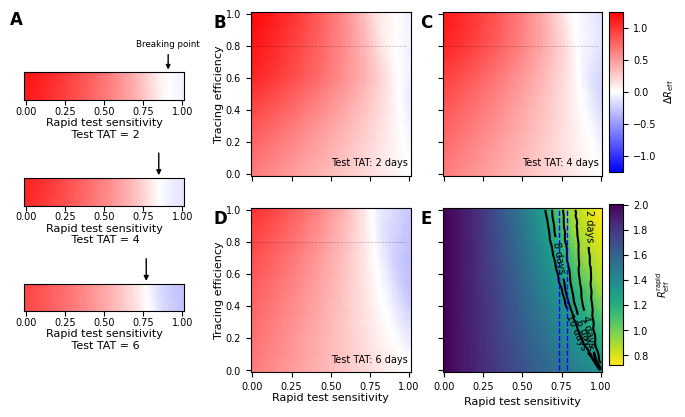

In [4]:
# make figure 2
InitialNumberOfInfected = 100
NumberOfExperiments = 50
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "negativebinomial"
directory = "outputsFinal"

# Define heatmap file
Poisson_Poisson = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"

tenbyten = Poisson_Poisson
x,y,z = make_raw_arrays(tenbyten)


# Now define paths to delayed simulations
delays = {1:{}, 2:{}, 3:{}, 4:{}, 5:{}}

delays = {1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}}

delays = {2:{}, 4:{}, 6:{}, 8:{}, 10:{}}




for key in delays.keys() :
    WaitBeforeTestTaken = 1
    WaitBeforeTestResult = key-1
    delays[key]['filename'] = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"


    delays[key]['x'],delays[key]['y'],delays[key]['z']= make_raw_arrays(delays[key]['filename'])
    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(delays[key]['x'],delays[key]['y'],delays[key]['z'])
    delays[key]['ydict'] = { delays[key]['Y'][i][0] : delays[key]['Z'][i][0] for i in range(0, len(delays[key]['Z']) ) }

contours = get_contours(x,y,z,delays)


for key in delays.keys():
    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']),np.array(contours[key]['y']),np.array(contours[key]['z']))

    
    
# PLOT
for key in delays.keys():
    delays[key]['x'],delays[key]['y'],delays[key]['z'] = make_raw_arrays(delays[key]['filename'])

    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(delays[key]['x'],delays[key]['y'],delays[key]['z'])
    delays[key]['ydict'] = { delays[key]['Y'][i][0] : delays[key]['Z'][i][0] for i in range(0, len(delays[key]['Z']) ) }
contours = get_contours(x,y,z,delays)


for key in delays.keys() :
    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']),np.array(contours[key]['y']),np.array(contours[key]['z']))


x,y,z = make_raw_arrays(tenbyten)
contours = get_contours(x,y,z,delays)
X,Y,Z = make_cbar_arrays(x,y,z)

# Plot the figure
make_fig2(X,Y,Z,delays,figname=f'Fig2{OffspringDistribution}', testSensitivity = True)

Create several smaller figures

0 :  baseline


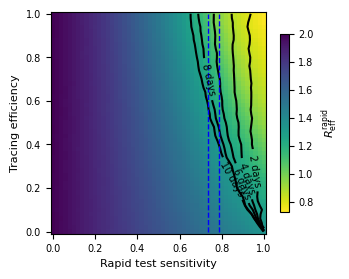

1 :  Geometric offspring


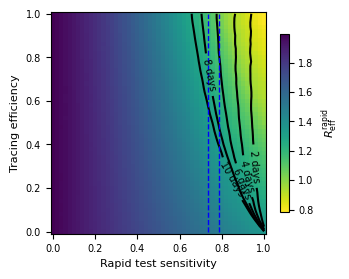

2 :  Poisson offspring


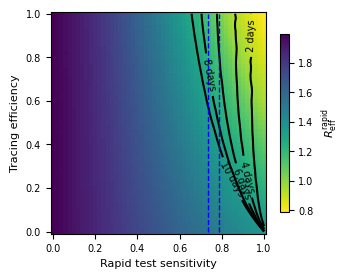

3 :  Flat skewed infectiousprofile


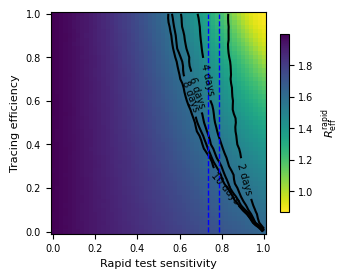

4 :  R0=3.0


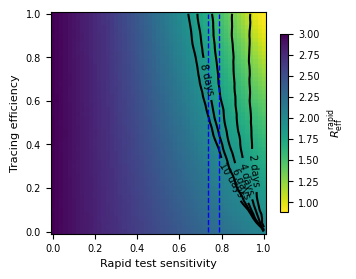

5 :  R0=10.0


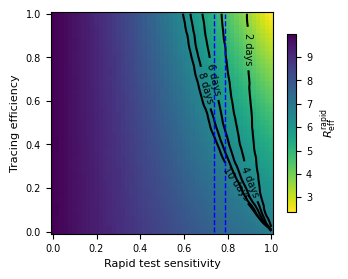

6 :  Asymptomatic=0.6


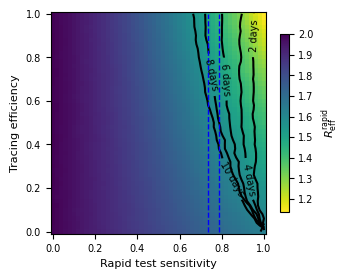

7 : viral load dependent test sensitivity


/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/3298429990.py:213: UserWarning: Adding colorbar to a different Figure <Figure size 350.394x280.315 with 2 Axes> than <Figure size 350.394x280.315 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, shrink=0.8)


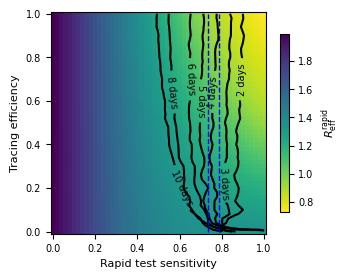

In [5]:
from matplotlib.lines import Line2D

param_settings_baseline_poisson = [
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "baseline"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "Flatskewed", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Flat skewed infectiousprofile"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 3.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "empirical", "title": "R₀=3.0, Asymptomatic=0.3", "keyword": "R0=3.0"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 10.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "empirical", "title": "R₀=10.0, Asymptomatic=0.3", "keyword": "R0=10.0"},
    {"AsymptomaticFractionOfInfected": 0.6, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.6", "keyword": "Asymptomatic=0.6"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'geometric', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Geometric offspring"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Negative binomial offspring"}
]

param_settings_baseline_negativebinomial = [
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 500, "R0": 2.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "baseline"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'geometric', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Geometric offspring"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 50, "R0": 2.0, 'OffspringDistributiong': 'poisson', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Poisson offspring"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 500, "R0": 2.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "Flatskewed", "title": "R₀=2.0, Asymptomatic=0.3", "keyword": "Flat skewed infectiousprofile"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 500, "R0": 3.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "empirical", "title": "R₀=3.0, Asymptomatic=0.3", "keyword": "R0=3.0"},
    {"AsymptomaticFractionOfInfected": 0.3, "no_exp": 500, "R0": 10.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "empirical", "title": "R₀=10.0, Asymptomatic=0.3", "keyword": "R0=10.0"},
    {"AsymptomaticFractionOfInfected": 0.6, "no_exp": 500, "R0": 2.0, 'OffspringDistributiong': 'negativebinomial', "infectiousprofile": "empirical", "title": "R₀=2.0, Asymptomatic=0.6", "keyword": "Asymptomatic=0.6"},
    
]
gauss_smooth = 0.75

InitialNumberOfInfected = 100
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
directory = "outputsFinal"

for subplot_idx, params in enumerate(param_settings_baseline_negativebinomial):
    print(subplot_idx, ": ",params["keyword"])
    fig = plt.figure(figsize= figsize2)
    R0 = params["R0"]
    AsymptomaticFractionOfInfected = params["AsymptomaticFractionOfInfected"]
    InfectiousProfile = params["infectiousprofile"]
    OffspringDistribution = params["OffspringDistributiong"]
    no_exp = params["no_exp"]
    
    try:
        # Define heatmap file
        Poisson_Poisson = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{no_exp}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"

        tenbyten = Poisson_Poisson
        x, y, z = make_raw_arrays(tenbyten)

        # Now define paths to delayed simulations
        delays = {2:{},4:{},6:{},8:{},10:{}}

        # Load delay files
        for key in delays.keys():
            WaitBeforeTestTaken_delay = 1
            WaitBeforeTestResult_delay = key - 1
            delays[key]['filename'] = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{no_exp}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken_delay}_WaitBeforeTestResult{WaitBeforeTestResult_delay}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"

            delays[key]['x'], delays[key]['y'], delays[key]['z'] = make_raw_arrays(delays[key]['filename'])
            delays[key]['X'], delays[key]['Y'], delays[key]['Z'] = make_cbar_arrays(delays[key]['x'], delays[key]['y'], delays[key]['z'])
            delays[key]['ydict'] = {delays[key]['Y'][i][0]: delays[key]['Z'][i][0] for i in range(0, len(delays[key]['Z']))}

        contours = get_contours(x, y, z, delays)

        for key in delays.keys():
            delays[key]['X'], delays[key]['Y'], delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']), np.array(contours[key]['y']), np.array(contours[key]['z']))

        # PLOT
        for key in delays.keys():
            delays[key]['x'], delays[key]['y'], delays[key]['z'] = make_raw_arrays(delays[key]['filename'])
            delays[key]['X'], delays[key]['Y'], delays[key]['Z'] = make_cbar_arrays(delays[key]['x'], delays[key]['y'], delays[key]['z'])
            delays[key]['ydict'] = {delays[key]['Y'][idx][0]: delays[key]['Z'][idx][0] for idx in range(0, len(delays[key]['Z']))}

        contours = get_contours(x, y, z, delays)

        for key in delays.keys():
            delays[key]['X'], delays[key]['Y'], delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']), np.array(contours[key]['y']), np.array(contours[key]['z']))

        x, y, z = make_raw_arrays(tenbyten)
        contours = get_contours(x, y, z, delays)
        X, Y, Z = make_cbar_arrays(x, y, z)

        Z = Z[:, ::-1]
        for key in delays.keys():
            delays[key]['Z'] = delays[key]['Z'][:, ::-1]

        im = plt.pcolormesh(X, Y, gaussian_filter(Z, gauss_smooth), cmap='viridis_r')

        # Plot contour lines with error checking
        for delay_idx, key in enumerate(delays.keys()):
            ZZ = copy.copy(delays[key]['Z'])
            ZZ = gaussian_filter(delays[key]['Z'], gauss_smooth)
            
            # Only plot contour if ZZ has proper 2D shape
            if ZZ.ndim == 2 and ZZ.shape[0] > 1 and ZZ.shape[1] > 1:
                ct = plt.contour(delays[key]['X'], delays[key]['Y'], ZZ, [0], cmap=cm.gray)
                plt.clabel(ct, ct.levels, inline=True, fmt='%s days' % key)
            else:
                print(f"    Skipping contour for delay {key} due to invalid shape: {ZZ.shape}")

        plt.xlabel('Rapid test sensitivity', fontsize=8)
        plt.ylabel('Tracing efficiency', fontsize=8)
        #plt.title(f'R0={R0}, Asymptomatic fraction={AsymptomaticFractionOfInfected}, infectious profile={InfectiousProfile}', fontsize=7)
        plt.vlines(0.737, ymin=0, ymax=1, colors='blue', linestyles='dashed', linewidth=1)
        plt.vlines(0.787, ymin=0, ymax=1, colors='blue', linestyles='dashed', linewidth=1)
        
        # Create individual colorbar for each subplot
        cbar = fig.colorbar(im, shrink=0.8)
        cbar.set_label(r'$R_{\rm eff}^{\rm rapid}$', fontsize=8)
        
    except Exception as e:
        plt.text(0.5, 0.5, f"Error loading data\nfor {params['title']}", 
                              horizontalalignment='center', verticalalignment='center',
                              transform=plt.transAxes, fontsize=12)
        plt.set_xlabel('Rapid test sensitivity', fontsize=8)
        plt.set_ylabel('Tracing efficiency', fontsize=8)
        #plt.set_title(f'R0={R0}, Asymptomatic fraction={AsymptomaticFractionOfInfected}, Infectious profile={InfectiousProfile}', fontsize=7)
    plt.tight_layout()
    figname = f'SI_{OffspringDistribution}_R0{R0}_Asymp{AsymptomaticFractionOfInfected}_infectiousProfile{InfectiousProfile}'
    plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
    plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
    plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
    plt.show()

plt.figure(figsize=figsize2)
InitialNumberOfInfected = 100
NumberOfExperiments = 500
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "negativebinomial"

print(subplot_idx+1, ": viral load dependent test sensitivity")

# Define heatmap file
if OffspringDistribution == "poisson":
    Poisson_Poisson = f"outputsFinal/JULIA_TestSensitivity_Istart100_Nexp50_R02.0_WaitBeforeTestTaken0_WaitBeforeTestResult0_Asymptomatics0.3_InfectiousProfileempirical_OffspringDistributionpoisson_Se.txt"
elif OffspringDistribution == "negativebinomial":
    Poisson_Poisson = f"outputsFinal/JULIA_TestSensitivity_Istart100_Nexp500_R02.0_WaitBeforeTestTaken0_WaitBeforeTestResult0_Asymptomatics0.3_InfectiousProfileempirical_OffspringDistributionnegativebinomial_Se.txt"

tenbyten = Poisson_Poisson
_,_,z = make_raw_arrays(tenbyten)

getxandy = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"
x,y,_ = make_raw_arrays(getxandy)

# Now define paths to delayed simulations
delays = {2:{},3:{},4:{},5:{},6:{},8:{},10:{}}



for key in delays.keys() :
    WaitBeforeTestTaken = 1
    WaitBeforeTestResult = key-1
    delays[key]['filename'] = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"


    delays[key]['x'],delays[key]['y'],delays[key]['z']= make_raw_arrays(delays[key]['filename'])
    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(delays[key]['x'],delays[key]['y'],delays[key]['z'])
    delays[key]['ydict'] = { delays[key]['Y'][i][0] : delays[key]['Z'][i][0] for i in range(0, len(delays[key]['Z']) ) }

contours = get_contours(x,y,z,delays)


# for key in delays.keys() :
#     delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']),np.array(contours[key]['y']),np.array(contours[key]['z']))

    
    
# PLOT
for key in delays.keys():
    delays[key]['x'],delays[key]['y'],delays[key]['z'] = make_raw_arrays(delays[key]['filename'])

    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(delays[key]['x'],delays[key]['y'],delays[key]['z'])
    delays[key]['ydict'] = { delays[key]['Y'][i][0] : delays[key]['Z'][i][0] for i in range(0, len(delays[key]['Z']) ) }
contours = get_contours(x,y,z,delays)


for key in delays.keys() :
    delays[key]['X'],delays[key]['Y'],delays[key]['Z'] = make_cbar_arrays(np.array(contours[key]['x']),np.array(contours[key]['y']),np.array(contours[key]['z']))

subplot_idx = 6
X,Y,Z = make_cbar_arrays(x,y,z)

Z = Z[:, ::-1]
for key in delays.keys():
    delays[key]['Z'] = delays[key]['Z'][:, ::-1]



im = plt.pcolormesh(X, Y, gaussian_filter(Z, gauss_smooth), cmap='viridis_r')

# Plot contour lines with error checking
for delay_idx, key in enumerate(delays.keys()):
    ZZ = copy.copy(delays[key]['Z'])
    ZZ = gaussian_filter(delays[key]['Z'], gauss_smooth)
    
    # Only plot contour if ZZ has proper 2D shape
    if ZZ.ndim == 2 and ZZ.shape[0] > 1 and ZZ.shape[1] > 1:
        ct = plt.contour(delays[key]['X'], delays[key]['Y'], ZZ, [0], cmap=cm.gray)
        if delay_idx == 5:
            ct.set_label(r"$\Delta R_{\rm eff} = 0$")
            plt.clabel(ct, ct.levels, inline=True, fmt='%s days' % key)
        else:
            plt.clabel(ct, ct.levels, inline=True, fmt='%s days' % key)
    else:
        print(f"    Skipping contour for delay {key} due to invalid shape: {ZZ.shape}")

plt.xlabel('Rapid test sensitivity', fontsize=8)
plt.ylabel('Tracing efficiency', fontsize=8)
#plt.title(f'test sensitivity is affected by viral load (infectious profile)', fontsize=7)

plt.vlines(0.737, ymin=0, ymax=1, colors='blue', linestyles='dashed', linewidth=1)
plt.vlines(0.787, ymin=0, ymax=1, colors='blue', linestyles='dashed', linewidth=1, label='Rapid test sensitivity interval reported from Wikipedia')
cbar = fig.colorbar(im, shrink=0.8)
cbar.set_label(r'$R_{\rm eff}^{\rm rapid}$', fontsize=8)
# Get the legend handles and labels from axes[subplot_idx]
# handles, labels = plt.get_legend_handles_labels()


# Create individual colorbar for each subplot


# axes[7].axis('off')  # Hide the last subplot (8th) if not used


plt.tight_layout()
figname = f'Fig3_Supplement_TestSensitivity_ViralLoadEffect_{OffspringDistribution}'
plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
plt.show()

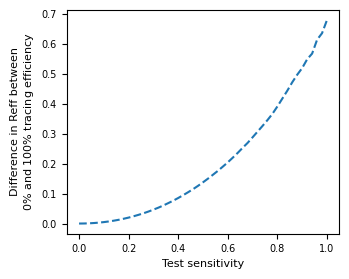

In [6]:
#reviewer 1s proposal figure. Zero tracing vs full tracing. 
InitialNumberOfInfected = 100
NumberOfExperiments = 50
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "poisson"
directory = "outputsFinal"

# Define heatmap file
filename = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"

df = pd.read_csv(filename)
    
x = np.array(df['False negative test rate'])
y = np.array(df['Tracing efficiency'])
ztheory = np.array(df['ReffTheoretical'])

difference = ztheory[:51] - ztheory[-51:]
plt.figure(figsize=figsize2) 
plt.plot(x[:51], difference[::-1], linestyle='dashed')
plt.xlabel('Test sensitivity', fontsize=8)
plt.ylabel('Difference in Reff between\n$0\\%$ and $100\\%$ tracing efficiency', fontsize=8)
figname = 'ContactTracingIsoloatedImpact'
plt.tight_layout()
plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
plt.show()

/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/2340391000.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r', len(contact_tracing_points))
/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/2340391000.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('viridis_r'))  # continuous gradient


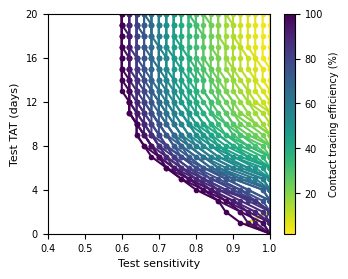

In [7]:
viralload = False

contact_tracing_points = [10, 20, 30, 40, 50]
# #contact_tracing_points = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
contact_tracing_points = np.arange(1,51) # corresponding to 20%, 40%, 60%, 80%, 100% tracing efficiency
cmap = cm.get_cmap('viridis_r', len(contact_tracing_points))

InitialNumberOfInfected = 100
NumberOfExperiments = 50
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "poisson"
directory = "outputsFinal"


# Define heatmap file
filename = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"

df = pd.read_csv(filename)    
x = np.array(df['False negative test rate'])
y = np.array(df['Tracing efficiency'])

if viralload:
    filename = "OutputspfalseDistribution/JULIA_TestSensitivity_Istart100_Nexp50_R02.0_WaitBeforeTestTaken0_WaitBeforeTestResult0_Asymptomatics0.3_InfectiousProfileempirical_OffspringDistributionpoisson.txt"
df = pd.read_csv(filename)    
z = np.array(df['ReffMean'])  
delays = {1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}, 11:{}, 12:{}, 13:{}, 14:{}, 15:{}, 16:{}, 17:{}, 18:{}, 19:{}, 20:{}}


for key in delays.keys() :
    WaitBeforeTestTaken = 1
    WaitBeforeTestResult = key-1
    filename = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"
    df_delay = pd.read_csv(filename)




plt.figure(figsize=figsize2)
for i, ct in enumerate(contact_tracing_points):
    breakingpoint_sensitivity = []
    breakpoint_TAT = []
    # z[k*51:k*51+51][::-1]
    breakingpoint_sensitivity.append(1)
    breakpoint_TAT.append(0)
    for key in delays.keys():
        WaitBeforeTestTaken = 1
        WaitBeforeTestResult = key-1
        filename = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"
        df_delay = pd.read_csv(filename)
        delay_Reff = np.array(df_delay['ReffMean'])


        breakingpoint_sensitivity.append(x[np.argmin(np.abs(z[ct*51:ct*51+51][::-1] - delay_Reff))])
        breakpoint_TAT.append(key)

    
    plt.plot(breakingpoint_sensitivity, breakpoint_TAT, marker='o', markersize=3, color=cmap(i), label=f'{ct*2}% Tracing efficiency')
plt.ylabel('Test TAT (days)', fontsize=8)
plt.xlabel('Test sensitivity', fontsize=8)
plt.xlim(0.4, 1.0)
plt.yticks(np.arange(0, 21, 4))
plt.ylim(0, 20)
norm = plt.Normalize(vmin=contact_tracing_points[0] * 2, vmax=contact_tracing_points[-1] * 2)
sm = cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('viridis_r'))  # continuous gradient
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Contact tracing efficiency (%)')
plt.tight_layout()
figname = 'Se_vs_TAT_ver2'
plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
plt.show()
# redegør for hvidt område "her er langsom test altid bedst uanset contact tracing". 

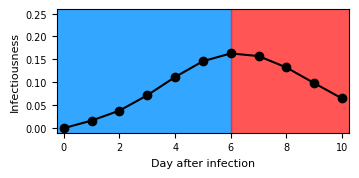

In [8]:
# Make Fig 1 B


import math
poisson = [0,0,0]
uniform = [0,0,0]
mean = 3
denominator = 0
for day in range (8) :
    poisson.append(mean**day/math.factorial(day)*math.exp(-mean))
    denominator += mean**day/math.factorial(day)*math.exp(-mean)
    
    uniform.append(1/8)

poisson = np.array(poisson)/denominator

empirical = [0,0.016594101174160984, 0.03825989639872386, 0.07179753940214578, 0.11163203061828501, 0.14606849688128792, 0.16307160173496651, 0.15722960662992053, 0.13234893246837098, 0.09820451847692209, 0.06479327621521616]
flatskewed = [0,0.12500000000000003, 0.12500000000000003, 0.12500000000000003, 0.12500000000000003, 0.12500000000000003, 0.12500000000000003, 0.06250000000000001, 0.06250000000000001, 0.06250000000000001, 0.06250000000000001]

SMALL_SIZE = 7
MEDIUM_SIZE = 8#10


plt.figure(figsize=(3.6,3.6/2))

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels


myGreen = '#00a000ff'
myBlue = '#0090ffff'
myRed = '#ff2a2aff'



plt.fill_between(np.arange(-1,6.1,.1),-1,0.30,color=myBlue,alpha=0.8)
plt.fill_between(np.arange(6,11.1,.1),-1,0.30,color=myRed,alpha=0.8)

empiricalprofile = True
if empiricalprofile :
    plt.plot(empirical,'o-',color='k',label='Skæv')
else :
    plt.plot(flatskewed,'o-',color='k',label='Skæv')

#plt.plot(flatskewed,'o',color='C1',label='Flad')

plt.xlabel('Day after infection',fontsize=MEDIUM_SIZE)
plt.ylabel('Infectiousness',fontsize=MEDIUM_SIZE)
#plt.legend(loc=2,frameon=False,fontsize=14)
plt.tick_params(labelsize=12)
plt.ylim([-0.01,0.26])
plt.xlim([-0.25,10.25])

plt.tick_params(labelsize=SMALL_SIZE)
plt.tight_layout()
if empiricalprofile :
    plt.savefig('FiguresFinal/Pinf(t)_empirical.svg',dpi=400)
    plt.savefig('FiguresFinal/Pinf(t)_empirical.png',dpi=400)
    plt.savefig('FiguresFinal/Pinf(t)_empirical.pdf',dpi=400)

else :
    plt.savefig('FiguresFinal/Pinf(t)_flatskewed.svg',dpi=400)
    plt.savefig('FiguresFinal/Pinf(t)_flatskewed.png',dpi=400)
    plt.savefig('FiguresFinal/Pinf(t)_flatskewed.pdf',dpi=400)

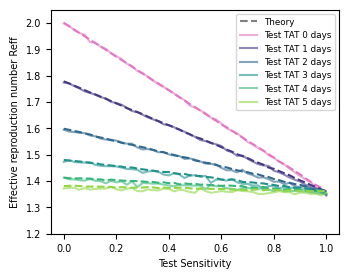

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

InitialNumberOfInfected = 100
NumberOfExperiments = 500
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "negativebinomial"
directory = "outputsFinal/"


# Define heatmap file
filename = f"{directory}JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}_no_tracing.txt"

df = pd.read_csv(filename)

y = np.array(df['False negative test rate'])
x = np.array(df['Tracing efficiency'])
Refftheoretical = np.array(df['ReffTheoretical'])
ReffMean = np.array(df['ReffMean'])   
Reffstd = np.array(df['ReffStd'])

plt.figure(figsize=figsize2)

plt.plot(np.unique(y),ReffMean[::-1],label='Test TAT 0 days',color='C6',markersize=4, alpha = 0.6)
#plt.fill_between(np.unique(y), ReffMean[::-1] - Reffstd[::-1], ReffMean[::-1] + Reffstd[::-1], color='C6', alpha=0.2)
plt.plot(np.unique(y),Refftheoretical[::-1],'--',label='Theory',color='C6')

for i in range(5):
    WaitBeforeTestTaken = 1
    WaitBeforeTestResult = i
    filename = f"{directory}JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}_no_tracing.txt"
    df = pd.read_csv(filename)
    Refftheoretical = np.array(df['ReffTheoretical'])

    ReffMean = np.array(df['ReffMean'])   
    Reffstd = np.array(df['ReffStd'])
    plt.plot(np.unique(y),ReffMean[::-1],label=f'Test TAT {i+1} days',markersize=4, color=cm.viridis((i+1)/6), alpha = 0.6)
    #plt.fill_between(np.unique(y), ReffMean[::-1] - Reffstd[::-1], ReffMean[::-1] + Reffstd[::-1], color=cm.viridis((i+1)/6), alpha=0.2)
    plt.plot(np.unique(y),Refftheoretical[::-1],'--',color=cm.viridis((i+1)/6))


plt.xlabel('Test Sensitivity')
plt.ylabel('Effective reproduction number Reff')
plt.ylim([1.2,R0+0.05])
# Get handles and labels from the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# Swap the order of the first two elements
if len(handles) >= 2:
    handles[0], handles[1] = handles[1], handles[0]
    labels[0], labels[1] = labels[1], labels[0]

# Create new legend with swapped order
legend = plt.legend(handles, labels)

for handle in legend.legend_handles:
    if handle.get_linestyle() == '--': 
        handle.set_color('grey')



plt.tight_layout()
#plt.title('Theoretical and simulated Reff vs. false negative rate and no tracing')
plt.savefig(f'{figuresDir}/Reff_vs_simulation_no_tracing_{OffspringDistribution}.svg',dpi=400)
plt.savefig(f'{figuresDir}/Reff_vs_simulation_no_tracing_{OffspringDistribution}.png',dpi=400)
plt.savefig(f'{figuresDir}/Reff_vs_simulation_no_tracing_{OffspringDistribution}.pdf',dpi=400)
plt.show()

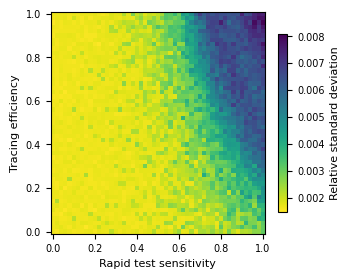

In [10]:
plt.figure(figsize=figsize2)
InitialNumberOfInfected = 100
NumberOfExperiments = 500
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "negativebinomial"
directory = "outputsFinal/"


getxandy = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"
df = pd.read_csv(getxandy)

x = np.array(df['False negative test rate'])
y = np.array(df['Tracing efficiency'])
z = np.array(df['ReffStd'])
zreal = np.array(df['ReffMean'])


X,Y,Z = make_cbar_arrays(x,y,z/zreal)

Z = Z[:, ::-1]

im = plt.pcolormesh(X, Y,gaussian_filter(Z,0.25), cmap='viridis_r')


plt.xlabel('Rapid test sensitivity', fontsize=8)
plt.ylabel('Tracing efficiency', fontsize=8)
#plt.title(f'test sensitivity is affected by viral load (infectious profile)', fontsize=7)

cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label(r'Relative standard deviation', fontsize=8)
# Get the legend handles and labels from axes[subplot_idx]
# handles, labels = plt.get_legend_handles_labels()


# Create individual colorbar for each subplot


# axes[7].axis('off')  # Hide the last subplot (8th) if not used


plt.tight_layout()
figname = f'standard_deviation_plot_{OffspringDistribution}'
plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
plt.show()

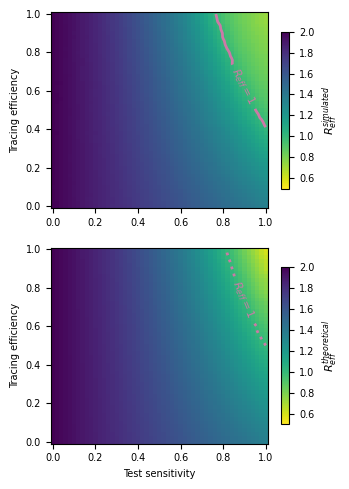

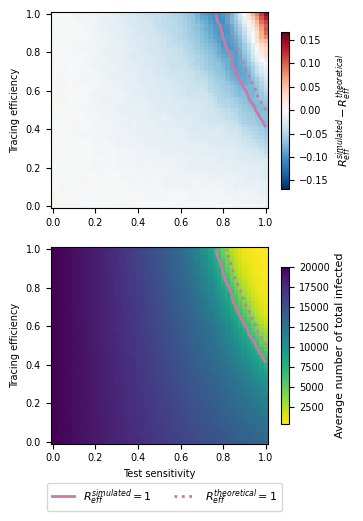

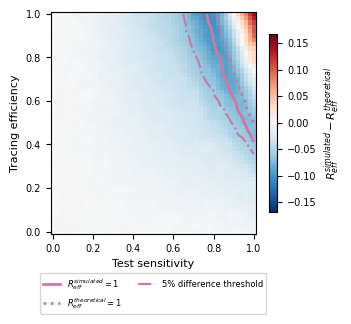

In [11]:
from matplotlib.lines import Line2D
x = np.linspace(0, 1, 51)
y = np.linspace(0, 1, 51)  
X, Y = np.meshgrid(x, y)


InitialNumberOfInfected = 100
NumberOfExperiments = 500
R0 = 2.0
WaitBeforeTestTaken = 0
WaitBeforeTestResult = 0
AsymptomaticFractionOfInfected = 0.3
InfectiousProfile = "empirical"
OffspringDistribution = "negativebinomial"
directory = "outputsFinal"
gauss_smooth = 0.75

# Define heatmap file
filename = f"{directory}/JULIA_TestSensitivity_Istart{InitialNumberOfInfected}_Nexp{NumberOfExperiments}_R0{R0}_WaitBeforeTestTaken{WaitBeforeTestTaken}_WaitBeforeTestResult{WaitBeforeTestResult}_Asymptomatics{AsymptomaticFractionOfInfected}_InfectiousProfile{InfectiousProfile}_OffspringDistribution{OffspringDistribution}.txt"
df = pd.read_csv(filename)

x = np.array(df['False negative test rate']).reshape(51, 51)[:,::-1]
y = np.array(df['Tracing efficiency']).reshape(51, 51)
Refftheoretical = np.array(df['ReffTheoretical']).reshape(51, 51)[:,::-1]

ReffMean = np.array(df['ReffMean']).reshape(51, 51)[:,::-1]
endedpandemics = np.array(df['N_infected_done']).reshape(51, 51)[:,::-1]
# Create figure with three subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(figsize2[0], figsize2[1]*2))

# Heatmap 1: ReffMean
im1 = ax1.pcolormesh(X, Y, gaussian_filter(ReffMean,  gauss_smooth), cmap='viridis_r', vmin=0.5, vmax=2)
ax1.set_ylabel('Tracing efficiency')
#ax1.set_xlabel('Test sensitivity')
#ax1.set_title('Reff Simulation')
cbar = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar.set_label(r'$R_{eff}^{simulated}$', fontsize=8)

contour1 = ax1.contour(X, Y, ReffMean, levels=[1.0], colors="#CC79A7", linewidths=2)
ax1.clabel(contour1, inline=True, fontsize=8, fmt=r'$R_{eff}=1$')

# Heatmap 2: Refftheoretical
im2 = ax2.pcolormesh(X, Y, gaussian_filter(Refftheoretical, gauss_smooth), cmap='viridis_r', vmin=0.5, vmax=2)
ax2.set_ylabel('Tracing efficiency')
ax2.set_xlabel('Test sensitivity')
#ax2.set_title('Reff Theoretical')
cbar = plt.colorbar(im2, ax=ax2, shrink=0.8)
cbar.set_label(r'$R_{eff}^{theoretical}$', fontsize=8)

contour2 = ax2.contour(X, Y, Refftheoretical, levels=[1.0], colors="#CC79A7", linewidths=2, linestyles='dotted')
ax2.clabel(contour2, inline=True, fontsize=8, fmt=r'$R_{eff}=1$')

legend_elements = [Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{simulated}=1$'),
                   Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{theoretical}=1$', linestyle='dotted')]#,
#                   Line2D([0], [0], color='#2ca02c', lw=2, label='Total infected = 100k')]
#fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.45, -0.02), ncol=3, fontsize = 8)

plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part1.svg',dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part1.png',dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part1.pdf',dpi=400, bbox_inches='tight')
plt.show()

fig, ( ax3, ax4)  = plt.subplots(2, 1, figsize=(figsize2[0], figsize2[1]*2))

# Heatmap 3: Difference (ReffMean - Refftheoretical)
difference = ReffMean - Refftheoretical
im3 = ax3.pcolormesh(X, Y, gaussian_filter(difference,  gauss_smooth), cmap='RdBu_r', vmin=-np.max(np.abs(difference)), vmax=np.max(np.abs(difference)))
ax3.set_ylabel('Tracing efficiency')
#ax3.set_xlabel('Test sensitivity')
#ax3.set_title('Difference')
cbar = plt.colorbar(im3, ax=ax3, shrink=0.8)
cbar.set_label(r'$R_{eff}^{simulated} - R_{eff}^{theoretical}$', fontsize=8)

contour3 = ax3.contour(X, Y, Refftheoretical, levels=[1.0], colors="#CC79A7", linewidths=2, linestyles='dotted')

contour4 = ax3.contour(X, Y, ReffMean, levels=[1.0], colors="#CC79A7", linewidths=2)


# im4 = ax4.imshow(gaussian_filter(endedpandemics, 0.25), extent=[x.min(),x.max(), y.min(), y.max()], origin='lower', cmap='viridis', aspect='auto')

im4 = ax4.pcolormesh(X, Y, gaussian_filter(endedpandemics, gauss_smooth), cmap='viridis_r')
ax4.set_ylabel('Tracing efficiency')
ax4.set_xlabel('Test sensitivity')
#ax4.set_title('Total infected in simulation')
cbar = plt.colorbar(im4, ax=ax4, shrink=0.8)
cbar.set_label(r'Average number of total infected', fontsize=8)

contour5 = ax4.contour(X, Y, Refftheoretical, levels=[1.0], colors="#CC79A7", linewidths=2, linestyles='dotted')
contour6 = ax4.contour(X, Y, ReffMean, levels=[1.0], colors="#CC79A7", linewidths=2)


# Create legend with contour line labels
legend_elements = [Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{simulated}=1$'),
                   Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{theoretical}=1$', linestyle='dotted')]

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.45, -0.02), ncol=3, fontsize = 8)

plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part2.svg',dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part2.png',dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/SI_Reff_vs_simulation_with_tracing_part2.pdf',dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(figsize2[0], figsize2[1]))
plt.pcolormesh(X, Y, gaussian_filter(difference,  gauss_smooth), cmap='RdBu_r', vmin=-np.max(np.abs(difference)), vmax=np.max(np.abs(difference)))
cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'$R_{eff}^{simulated} - R_{eff}^{theoretical}$', fontsize=8)
contour8 = plt.contour(X, Y, Refftheoretical, levels=[1.0], colors="#CC79A7", linewidths=2, linestyles='dotted')
#plt.clabel(contour8, inline=True, fontsize=8)
contour9 = plt.contour(X, Y, ReffMean, levels=[1.0], colors="#CC79A7", linewidths=2)
#plt.clabel(contour9, inline=True, fontsize=8)
contour10 = plt.contour(X, Y, np.abs(gaussian_filter(difference/Refftheoretical*100,  gauss_smooth)), levels=[5], colors="#CC79A7", linewidths=2, alpha=0)
contour_segments = contour10.allsegs[0]  # Get segments for the first (and only) level
leftmost_segment = min(contour_segments, key=lambda seg: np.min(seg[:, 0]))
plt.plot(leftmost_segment[:, 0], leftmost_segment[:, 1], 
             color="#CC79A7", linewidth=1.5, label='5% difference threshold', linestyle='-.')

legend_elements = [Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{simulated}=1$'),
                   Line2D([0], [0], color="#CC79A7", lw=2, label=r'$R_{eff}^{theoretical}=1$', linestyle='dotted'),
                   Line2D([0], [0], color="#CC79A7", lw=1.5, label='5% difference threshold', linestyle='-.')]

plt.ylabel('Tracing efficiency', fontsize=8)
plt.xlabel('Test sensitivity', fontsize=8)
plt.tight_layout()
plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.38), ncol=2, fontsize = 6)

plt.savefig(f'{figuresDir}/Reff_vs_simulation_with_tracing.svg', dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/Reff_vs_simulation_with_tracing.png', dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/Reff_vs_simulation_with_tracing.pdf', dpi=400, bbox_inches='tight')
plt.show()


/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/95228053.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[k,j].set_ylim(0, 1)
/var/folders/mn/mfz3gv8d0sdcm1yybzx2fxwr0000gp/T/ipykernel_48933/95228053.py:34: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[k,j].set_ylim(-10, 1)


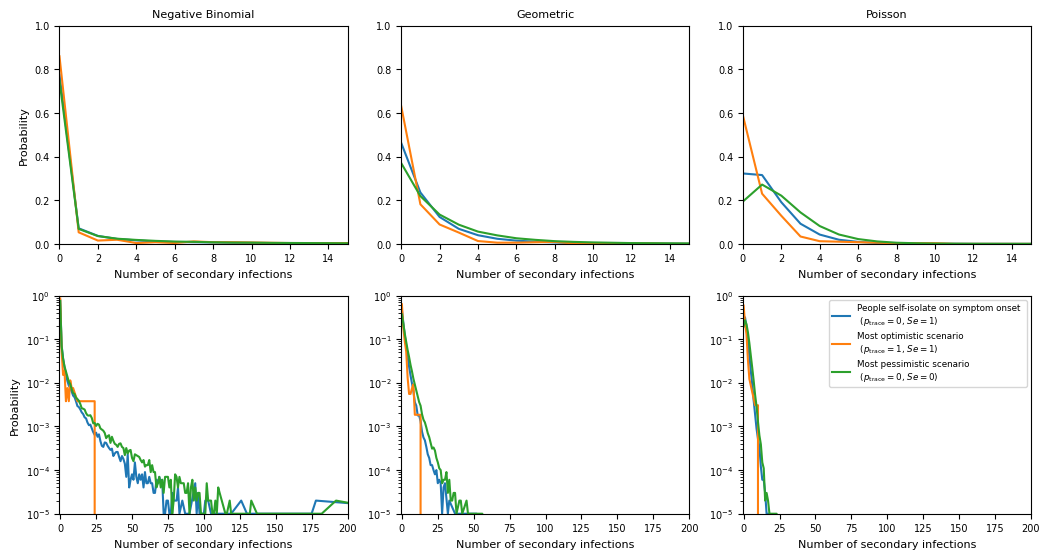

In [12]:
pfalse = [0.0,0.0,1.0]
contacttracing = [0.0,1.0,0.0]
dists = ['negativebinomial', 'geometric','poisson']
dist_name = {'negativebinomial':'Negative Binomial', 'geometric':'Geometric', 'poisson':'Poisson'}
titles = ['People self-isolate on symptom onset \n ($p_{\\rm trace} = 0$, $Se = 1$)', 'Most optimistic scenario \n ($p_{\\rm trace} = 1$, $Se = 1$)', 'Most pessimistic scenario \n ($p_{\\rm trace} = 0$, $Se = 0$)']
fig, axes = plt.subplots(2, 3, figsize=(figsize2[0]*3, figsize2[1]*2    ))
for i in range(3) :
    for j, d in enumerate(dists):
        for k in range(2):
            filename_offspring = "offspringdistributions/OffspringDistributionEff_pfalse_{}_contactTracing_{}_offspringdist_{}.txt".format(pfalse[i], contacttracing[i], d)

            offspring = np.loadtxt(filename_offspring)
            if k == 0:
                axes[k,j].set_title(dist_name[d], fontsize=8)
            x, counts = np.unique(offspring, return_counts=True)
            x_lim = np.concatenate((x, np.arange(np.max(x)+1,1001)))
            counts_final = np.concatenate((counts, np.zeros(len(np.arange(np.max(x)+1,1001)))))

            probs = counts_final / counts_final.sum()
            if k == 0:
                axes[k,j].plot(x_lim, probs, linewidth=1.5, label=titles[i])
            else:
                axes[k,j].plot(x_lim, probs, linewidth=1.5, label=titles[i])
                
            
            axes[k,j].set_ylim(0, 1)
            axes[k,j].set_xlim(0, 15)
            axes[k,j].set_xlabel('Number of secondary infections', fontsize=8)
            # axes[k,j].set_yscale('log')
            # axes[k,j].set_xscale('log')
            if j == 0:
                axes[k,j].set_ylabel('Probability', fontsize=8)
            if k == 1:
                axes[k,j].set_ylim(-10, 1)
                axes[k,j].set_yscale('log')
                axes[k,j].set_xlim(-0.5, 200)

#plt.suptitle('Offspring Distributions under different testing and tracing scenarios')
plt.tight_layout()
plt.legend()

plt.savefig(f'{figuresDir}/OffspringDistributions_Scenarios.svg', dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/OffspringDistributions_Scenarios.png', dpi=400, bbox_inches='tight')
plt.savefig(f'{figuresDir}/OffspringDistributions_Scenarios.pdf', dpi=400, bbox_inches='tight')
plt.show()




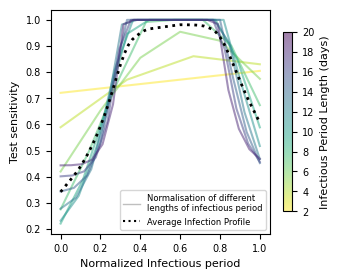

In [13]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap

figname = 'NormalizedInfectionTimes'

alpha = 0.5

x_grid = np.linspace(0, 1, 51)
avg_curve = np.array([0.342375718121345, 0.36093791581481377, 0.37950011369423514, 0.3980919437774591, 0.4175899652122049, 0.43989099974784285, 0.4650032868635595, 0.4926503826852703, 0.5231926115364881, 0.5564786656692143, 0.5937981658161181, 0.6342806897104397, 0.6789244084991375, 0.7281991291472295, 0.7788222436925472, 0.8280098158761775, 0.8708513314886647, 0.9035482829028681, 0.924898307233894, 0.9384063258133326, 0.9495186192976747, 0.9587059554717842, 0.9646832360784565, 0.9671070837547728, 0.9691890173270861, 0.9712709508993993, 0.9733528844717123, 0.9754348180440255, 0.9775167516163388, 0.9795134563521923, 0.9813951741785532, 0.9812466106503576, 0.981072991396239, 0.9808249053476856, 0.9800463735176504, 0.9788018759827253, 0.9763059947874454, 0.9709948462613374, 0.9641475415906999, 0.9525731734682512, 0.9342723044355482, 0.9086960386922863, 0.8761718178256035, 0.8417306531345256, 0.8046161304848357, 0.7679694423272142, 0.7315713801635215, 0.6980291458361093, 0.6672949470274536, 0.6370435298540537, 0.6067943026478495])
with open('OutputspfalseDistribution/samples_normalized_infection_times.txt', 'r') as f:
    infection_times = [eval(line.strip()) for line in f if line.strip()]
colormap = plt.get_cmap('viridis_r')

my_cmap = colormap(np.arange(colormap.N))

my_cmap[:, -1] = alpha
my_cmap = ListedColormap(my_cmap)

plt.figure(figsize=figsize2)
num_samples = 10
for i, times in enumerate(infection_times[:num_samples]):
    plt.plot(np.linspace(0,1,len(times)), times, color=my_cmap(i / num_samples), alpha=alpha)
plt.plot(x_grid, avg_curve, color='black', linestyle = 'dotted', linewidth=2, label='Average Infection Profile')

# Create colorbar

norm = mpl.colors.Normalize(vmin=2, vmax=20)
sm = mpl.cm.ScalarMappable(cmap=my_cmap, norm=norm)

sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
cbar.set_label('Infectious Period Length (days)', fontsize=8)


plt.xlabel('Normalized Infectious period', fontsize=8)
plt.ylabel('Test sensitivity', fontsize = 8)
# Create a grey line for the legend representing the individual curves
grey_line = Line2D([0], [0], color='grey', alpha=0.5, linewidth=1, label='Normalisation of different lengths of infectious period')
black_dotted = Line2D([0],[0], color='black', linestyle='dotted', label='Average Infection Profile')
plt.legend([grey_line, black_dotted], ['Normalisation of different\nlengths of infectious period', 'Average Infection Profile'], fontsize=6)

plt.tight_layout()
plt.savefig(f'{figuresDir}/{figname}.png',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.pdf',dpi=400)
plt.savefig(f'{figuresDir}/{figname}.svg',dpi=400)
plt.show()